# ARISTA Growth-Interaction Celltype Bubble

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import SVG, display

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'downstream_helpers').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from downstream_helpers import (
    AristaLegacyLineageConfig,
    resolve_arista_legacy_output_dir,
    run_arista_legacy_growth_interaction_celltype_bubble,
)

In [2]:
SMOKE_TEST = False
OUTPUT_DIR = resolve_arista_legacy_output_dir('arista_growth_interaction_celltype_bubble_notebook')

config = AristaLegacyLineageConfig(
    output_dir=str(OUTPUT_DIR),
    n_samples=1000 if SMOKE_TEST else 7668,
    classifier_epochs=1 if SMOKE_TEST else 1000,
    time_points=(0.0, 1.0, 2.0, 3.0, 4.0),
    interp_time_points=(0.5, 1.5, 2.5, 3.5),
    split_sde_dt=0.05,
    split_sigma=0.03,
    split_growth_alpha=1.0,
    classifier_knn_neighbors=10,
    use_real_for_observed=True,
    spatial_warp_to_observed_piecewise=False,
    spatial_warp_k=8,
    spatial_warp_eps=1e-6,
    random_seed=42,
)
config

AristaLegacyLineageConfig(output_dir='/Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/arista_growth_interaction_celltype_bubble_notebook', config_path='vendor/legacy_arista_stack/config/arista_config.yaml', annotation_csv='data/arista/arista_1108_with_annotation.csv', label_color_json='assets/arista/label_to_color.json', classifier_cache_path='assets/arista/classifier_cache/classifier_resmlp_a2ffc52825a81efd.pt', time_points=(0.0, 1.0, 2.0, 3.0, 4.0), interp_time_points=(0.5, 1.5, 2.5, 3.5), target_total_slices=None, use_real_for_observed=True, spatial_warp_to_observed_piecewise=False, spatial_warp_k=8, spatial_warp_eps=1e-06, classifier_knn_neighbors=10, random_seed=42, n_samples=7668, sde_dt=0.05, split_sde_dt=0.05, split_sigma=0.03, split_growth_alpha=1.0, classifier_epochs=1000, classifier_hidden=128, classifier_n_pcs=None, classifier_best_metric='bacc', classifier_train_on_full_data=False, classifier_save_test_models=False, classifier_last_k_epochs=5, classifier_

In [3]:
result = run_arista_legacy_growth_interaction_celltype_bubble(
    config,
    interaction_m=1024,
    interaction_threshold=1000.0,
    max_cells=None if not SMOKE_TEST else 600,
    seed=0,
)
result

Device: cpu
Experiment dir: /Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/vendor/legacy_arista_stack/results/arista_1110
[train_mlp_classifier] force-loaded cache: /Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/assets/arista/classifier_cache/classifier_resmlp_a2ffc52825a81efd.pt
Classifier val_acc: 0.7445334487984412
[simulate_sde_points] start | n_init=7668, ts_points=9, dt=0.05, sigma=0.0, include_score=False, t_range=(0.0,4.0), est_steps=80
[simulate_sde_points] done | timepoints=9, shape0=(7668, 52)
[simulate_sde_points_split] start | n_init=7668, ts_points=9, dt=0.05, sigma=0.03, growth_alpha=1.0, t_range=(0.0,4.0), est_steps=80
[simulate_sde_points_split] done | timepoints=9, shape0=(7664, 52)


AristaLegacyGrowthInteractionBubbleResult(output_dir=PosixPath('/Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/arista_growth_interaction_celltype_bubble_notebook'), bubble_svg=PosixPath('/Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/arista_growth_interaction_celltype_bubble_notebook/arista_growth_interaction_celltype_bubble.svg'), bubble_png=PosixPath('/Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/arista_growth_interaction_celltype_bubble_notebook/arista_growth_interaction_celltype_bubble.png'), raw_csv=PosixPath('/Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/arista_growth_interaction_celltype_bubble_notebook/arista_growth_interaction_raw.csv'), grouped_csv=PosixPath('/Users/zhenyizhang/Documents/GitHub/cytobridge-downstream/results/arista_growth_interaction_celltype_bubble_notebook/arista_growth_interaction_celltype_summary.csv'), output_files=['arista_growth_interaction_celltype_bubble.png', 'arista_growth

In [4]:
summary_df = pd.read_csv(result.grouped_csv)
summary_df.head()

,time,celltype,growth_mean,inter_mean,n
0,0.0,CMPN,0.015579,0.487695,669
1,0.0,MCG,0.015231,0.453134,121
2,0.0,MSN,-0.055880,0.815978,797
3,0.0,Oligo,0.009169,0.457409,92
4,0.0,VLMC,-0.011410,0.762935,1300


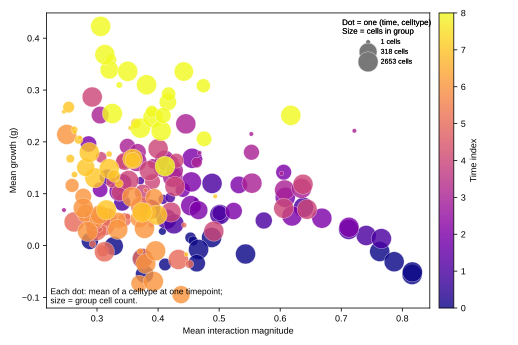

In [5]:
display(SVG(filename=str(result.bubble_svg)))